In [1]:
import pandas as pd 
import numpy as np 

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

In [9]:
data = {
    "date_posted": pd.date_range(start="2026-01-01", periods=20),
    "hook": [
        "Why you can't lose weight",
        "Stop doing this at night",
        "Mental health truth",
        "Hidden anxiety signs",
        "Weight loss mistake",
        "Sleep affects weight",
        "Stress and fat gain",
        "Why diets fail",
        "Your brain and sugar",
        "Confidence secret",
        "Trauma and eating",
        "Night eating causes",
        "Hydration weight myth",
        "Metabolism truth",
        "Weight loss psychology",
        "Food addiction truth",
        "Emotional eating signs",
        "Hidden stress signals",
        "Burnout warning",
        "Gut health truth"
    ],
    "video_type": np.random.choice(["Emotional", "Curiosity", "Authority", "POV"], size=20),
    "platform": np.random.choice(
        ["TikTok", "Instagram"],
        size=20
    ),
    "views": np.random.randint(500, 50000, size=20),
    "likes": np.random.randint(50, 5000, size=20),
    "shares": np.random.randint(5, 1000, size=20),
    "saves": np.random.randint(5, 800, size=20),
    "comments": np.random.randint(5, 600, size=20)
}


In [33]:
df = pd.DataFrame(data)
df.to_csv("Social-media-Analytics-tool-data.csv")

In [12]:
df.dtypes

date_posted    datetime64[ns]
hook                   object
video_type             object
platform               object
views                   int32
likes                   int32
shares                  int32
saves                   int32
comments                int32
dtype: object

In [13]:
df.isnull().sum()

date_posted    0
hook           0
video_type     0
platform       0
views          0
likes          0
shares         0
saves          0
comments       0
dtype: int64

In [14]:
df["weighted_engagement"] = (
    df["likes"]
    + df["shares"] * 2
    + df["saves"] * 3
    + df["comments"] * 2
)

In [15]:
df["engagement_score"] = (
    df["weighted_engagement"] / df["views"]
) * 100

In [1]:
df

NameError: name 'df' is not defined

In [16]:
def classify(score):
    if score > 10:
        return "SCALE"
    elif score < 3:
        return "KILL"
    else:
        return "ITERATE"

df["status"] = df["engagement_score"].apply(classify)

In [17]:
df.head()

,date_posted,hook,video_type,platform,views,likes,shares,saves,comments,weighted_engagement,engagement_score,status
0,2026-01-01,Why you can't lose weight,Emotional,Instagram,15929,1858,133,347,535,4235,26.586729,SCALE
1,2026-01-02,Stop doing this at night,POV,TikTok,13790,2386,443,145,598,4903,35.554750,SCALE
2,2026-01-03,Mental health truth,Authority,TikTok,34592,4439,621,319,534,7706,22.276827,SCALE
3,2026-01-04,Hidden anxiety signs,Emotional,TikTok,25822,57,372,38,357,1629,6.308574,ITERATE
4,2026-01-05,Weight loss mistake,Emotional,Instagram,21006,4648,710,153,313,7153,34.052176,SCALE


In [18]:
df

,date_posted,hook,video_type,platform,views,likes,shares,saves,comments,weighted_engagement,engagement_score,status
0,2026-01-01,Why you can't lose weight,Emotional,Instagram,15929,1858,133,347,535,4235,26.586729,SCALE
1,2026-01-02,Stop doing this at night,POV,TikTok,13790,2386,443,145,598,4903,35.554750,SCALE
2,2026-01-03,Mental health truth,Authority,TikTok,34592,4439,621,319,534,7706,22.276827,SCALE
3,2026-01-04,Hidden anxiety signs,Emotional,TikTok,25822,57,372,38,357,1629,6.308574,ITERATE
4,2026-01-05,Weight loss mistake,Emotional,Instagram,21006,4648,710,153,313,7153,34.052176,SCALE
5,2026-01-06,Sleep affects weight,Authority,Instagram,5051,4572,721,652,585,9140,180.954266,SCALE
6,2026-01-07,Stress and fat gain,Authority,TikTok,21736,1082,864,363,143,4185,19.253773,SCALE
7,2026-01-08,Why diets fail,Authority,TikTok,16561,3676,285,466,290,6224,37.582272,SCALE
8,2026-01-09,Your brain and sugar,Authority,Instagram,13838,2850,466,443,19,5149,37.209134,SCALE
9,2026-01-10,Confidence secret,Curiosity,TikTok,1244,439,647,750,291,4565,366.961415,SCALE


In [19]:
df.groupby("platform")["engagement_score"].mean()

platform
Instagram     47.002941
TikTok       121.871514
Name: engagement_score, dtype: float64

In [20]:
df.groupby("video_type")["engagement_score"].mean()

video_type
Authority     92.142010
Curiosity    186.654141
Emotional     94.204625
POV           48.512047
Name: engagement_score, dtype: float64

In [21]:
df["status"].value_counts()

status
SCALE      18
ITERATE     2
Name: count, dtype: int64

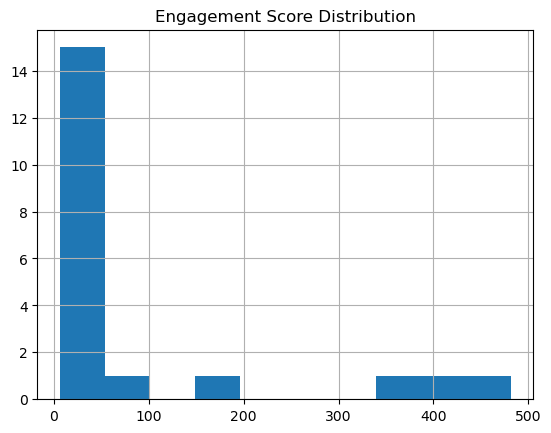

In [22]:
df["engagement_score"].hist()
plt.title("Engagement Score Distribution")
plt.show()

In [23]:
df.to_csv("social_media_analytics_results.csv", index=False)

In [27]:
df["week"] = pd.to_datetime(df["date_posted"]).dt.isocalendar().week
df.head()

,date_posted,hook,video_type,platform,views,likes,shares,saves,comments,weighted_engagement,engagement_score,status,week
0,2026-01-01,Why you can't lose weight,Emotional,Instagram,15929,1858,133,347,535,4235,26.586729,SCALE,1
1,2026-01-02,Stop doing this at night,POV,TikTok,13790,2386,443,145,598,4903,35.554750,SCALE,1
2,2026-01-03,Mental health truth,Authority,TikTok,34592,4439,621,319,534,7706,22.276827,SCALE,1
3,2026-01-04,Hidden anxiety signs,Emotional,TikTok,25822,57,372,38,357,1629,6.308574,ITERATE,1
4,2026-01-05,Weight loss mistake,Emotional,Instagram,21006,4648,710,153,313,7153,34.052176,SCALE,2


In [28]:
weekly_summary = df.groupby("week").agg({
    "views": "sum",
    "likes": "sum",
    "shares": "sum",
    "saves": "sum",
    "comments": "sum",
    "engagement_score": "mean"
}).reset_index()

weekly_summary

,week,views,likes,shares,saves,comments,engagement_score
0,1,90133,8740,1569,849,2024,22.681720
1,2,104378,19525,3964,3522,1851,99.611769
2,3,202210,17444,4254,3218,2377,92.219534
3,4,18816,8761,1024,1519,728,239.902131


In [29]:
top_hooks = df.sort_values("engagement_score", ascending=False)[
    ["hook", "engagement_score", "platform"]
].head(10)

top_hooks

,hook,engagement_score,platform
16,Emotional eating signs,481.783537,TikTok
18,Burnout warning,434.073724,TikTok
9,Confidence secret,366.961415,TikTok
5,Sleep affects weight,180.954266,Instagram
17,Hidden stress signals,91.430595,TikTok
19,Gut health truth,45.730539,TikTok
7,Why diets fail,37.582272,TikTok
8,Your brain and sugar,37.209134,Instagram
1,Stop doing this at night,35.554750,TikTok
4,Weight loss mistake,34.052176,Instagram


In [30]:
df["viral_score"] = (
    df["shares"] * 0.4 +
    df["saves"] * 0.3 +
    df["comments"] * 0.2 +
    df["likes"] * 0.1
)

In [31]:
df["viral_score"] = df["viral_score"] / df["viral_score"].max() * 100

In [32]:
df.to_csv("full_analytics_report.csv", index=False)
weekly_summary.to_csv("weekly_summary_report.csv", index=False)
top_hooks.to_csv("top_hooks_report.csv", index=False)

In [34]:
df

,date_posted,hook,video_type,platform,views,likes,shares,saves,comments
0,2026-01-01,Why you can't lose weight,Emotional,Instagram,15929,1858,133,347,535
1,2026-01-02,Stop doing this at night,POV,TikTok,13790,2386,443,145,598
2,2026-01-03,Mental health truth,Authority,TikTok,34592,4439,621,319,534
3,2026-01-04,Hidden anxiety signs,Emotional,TikTok,25822,57,372,38,357
4,2026-01-05,Weight loss mistake,Emotional,Instagram,21006,4648,710,153,313
5,2026-01-06,Sleep affects weight,Authority,Instagram,5051,4572,721,652,585
6,2026-01-07,Stress and fat gain,Authority,TikTok,21736,1082,864,363,143
7,2026-01-08,Why diets fail,Authority,TikTok,16561,3676,285,466,290
8,2026-01-09,Your brain and sugar,Authority,Instagram,13838,2850,466,443,19
9,2026-01-10,Confidence secret,Curiosity,TikTok,1244,439,647,750,291


In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 